# Chapter 7 Python Lab  
## Limits and Continuity in Several Variables

This lab accompanies **Chapter 7: Limits and Continuity in Several Variables**.

The main conceptual shift from one-variable calculus is that a point $(x,y)$ can approach
$(a,b)$ from infinitely many directions and along infinitely many paths. A two-variable
limit

$$
\lim_{(x,y)\to(a,b)} f(x,y)
$$

exists only when **all** ways of approaching $(a,b)$ lead to the same value.

This lab uses Python to investigate limits by:

- evaluating functions near a point,
- testing limits along lines and curves,
- visualizing surfaces near possible discontinuities,
- using polar coordinates numerically,
- exploring removable and non-removable discontinuities,
- studying continuity regions,
- and building a practical numerical limit diagnostic.

Only `numpy` and `matplotlib` are required.

## Learning goals

By the end of this lab, you should be able to:

1. evaluate a function near a point from many directions;
2. use path tests to show that a limit does not exist;
3. recognize when path evidence is suggestive but not a proof;
4. visualize a function near a suspected discontinuity;
5. use polar coordinates to understand limits at the origin;
6. investigate squeeze-type examples numerically;
7. classify removable, jump/path-dependent, and infinite discontinuities;
8. visualize continuity regions in the plane;
9. understand continuity of compositions built from standard continuous functions;
10. build and interpret numerical limit experiments responsibly.

## Source note

This notebook was generated from the uploaded Chapter 7 QMD file.  
The extracted early headings from the source file include:

- Chapter overview
- Learning goals
- 7.1 Why multivariable limits are different
- 7.2 The formal definition
- 7.3 Easy limits by continuity
- Example 7.1: Direct substitution
- Example 7.2: A rational function at a regular point
- 7.4 Path tests for nonexistence
- Example 7.3: A classic path-dependent limit
- 7.5 Checking only lines is not enough

## 0. Setup

Run this cell first.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

np.set_printoptions(precision=6, suppress=True)

def make_grid(xmin=-2, xmax=2, ymin=-2, ymax=2, n=250):
    x = np.linspace(xmin, xmax, n)
    y = np.linspace(ymin, ymax, n)
    X, Y = np.meshgrid(x, y)
    return x, y, X, Y

def safe_eval_2d(f, X, Y):
    with np.errstate(divide="ignore", invalid="ignore", over="ignore", under="ignore"):
        Z = f(X, Y)
    Z = np.asarray(Z, dtype=float)
    return Z

def make_3d_axes(title=None, elev=25, azim=35):
    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection="3d")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    if title:
        ax.set_title(title)
    ax.view_init(elev=elev, azim=azim)
    return fig, ax

def plot_surface_near(f, xmin=-1, xmax=1, ymin=-1, ymax=1, n=180,
                      title="Surface near a point", zlim=None, elev=30, azim=45):
    x, y, X, Y = make_grid(xmin, xmax, ymin, ymax, n)
    Z = safe_eval_2d(f, X, Y)
    fig, ax = make_3d_axes(title=title, elev=elev, azim=azim)
    ax.plot_surface(X, Y, Z, linewidth=0, alpha=0.85)
    if zlim is not None:
        ax.set_zlim(*zlim)
    plt.show()
    return X, Y, Z

def plot_contour_near(f, xmin=-1, xmax=1, ymin=-1, ymax=1, n=300,
                      levels=15, title="Contour plot near a point"):
    x, y, X, Y = make_grid(xmin, xmax, ymin, ymax, n)
    Z = safe_eval_2d(f, X, Y)
    fig, ax = plt.subplots(figsize=(7, 6))
    cs = ax.contour(X, Y, Z, levels=levels)
    ax.clabel(cs, inline=True, fontsize=8)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.25)
    plt.show()
    return X, Y, Z

def plot_heatmap_near(f, xmin=-1, xmax=1, ymin=-1, ymax=1, n=300,
                      title="Heatmap near a point", vmin=None, vmax=None):
    x, y, X, Y = make_grid(xmin, xmax, ymin, ymax, n)
    Z = safe_eval_2d(f, X, Y)
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(Z, extent=[xmin, xmax, ymin, ymax],
                   origin="lower", aspect="auto", vmin=vmin, vmax=vmax)
    fig.colorbar(im, ax=ax, label="function value")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title)
    ax.grid(True, alpha=0.25)
    plt.show()
    return X, Y, Z

def sample_along_path(f, x_path, y_path, t_values):
    x = x_path(t_values)
    y = y_path(t_values)
    z = safe_eval_2d(f, x, y)
    return x, y, z

def print_path_table(name, t_values, z_values, max_rows=10):
    print(name)
    print("-" * len(name))
    rows = min(len(t_values), max_rows)
    for i in range(rows):
        print(f"t = {t_values[i]: .6e}, f = {z_values[i]: .10f}")
    if len(t_values) > rows:
        print("...")

print("Setup complete.")

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-wbo24fve because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Setup complete.


---

# Part I. What is different about multivariable limits?

In one variable, $x\to a$ means $x$ approaches $a$ from the left or from the right.

In two variables, $(x,y)\to(a,b)$ means

$$
\sqrt{(x-a)^2+(y-b)^2}\to 0.
$$

There are infinitely many possible paths:

- horizontal lines,
- vertical lines,
- slanted lines,
- parabolas,
- spirals,
- piecewise paths,
- and many more.

A limit exists only if all approaches lead to the same number.

## 1. A first path-dependent example

Consider

$$
f(x,y)=\frac{x^2-y^2}{x^2+y^2}.
$$

At the origin, the formula is undefined. We investigate

$$
\lim_{(x,y)\to(0,0)}\frac{x^2-y^2}{x^2+y^2}.
$$

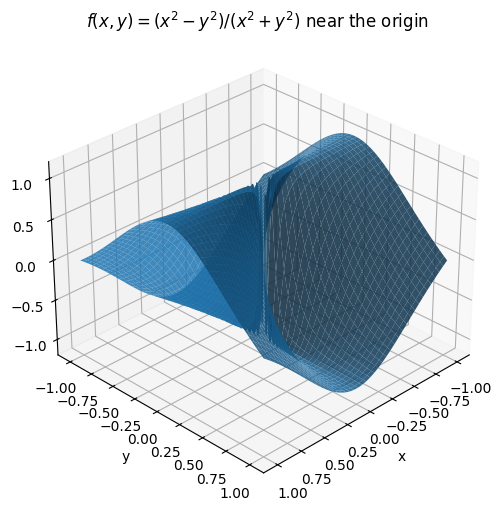

(array([[-1.      , -0.988827, -0.977654, ...,  0.977654,  0.988827,
          1.      ],
        [-1.      , -0.988827, -0.977654, ...,  0.977654,  0.988827,
          1.      ],
        [-1.      , -0.988827, -0.977654, ...,  0.977654,  0.988827,
          1.      ],
        ...,
        [-1.      , -0.988827, -0.977654, ...,  0.977654,  0.988827,
          1.      ],
        [-1.      , -0.988827, -0.977654, ...,  0.977654,  0.988827,
          1.      ],
        [-1.      , -0.988827, -0.977654, ...,  0.977654,  0.988827,
          1.      ]], shape=(180, 180)),
 array([[-1.      , -1.      , -1.      , ..., -1.      , -1.      ,
         -1.      ],
        [-0.988827, -0.988827, -0.988827, ..., -0.988827, -0.988827,
         -0.988827],
        [-0.977654, -0.977654, -0.977654, ..., -0.977654, -0.977654,
         -0.977654],
        ...,
        [ 0.977654,  0.977654,  0.977654, ...,  0.977654,  0.977654,
          0.977654],
        [ 0.988827,  0.988827,  0.988827, ...,  0.9888

In [2]:
def f_path_dependent(X, Y):
    return (X**2 - Y**2) / (X**2 + Y**2)

plot_surface_near(
    f_path_dependent,
    xmin=-1, xmax=1, ymin=-1, ymax=1,
    title=r"$f(x,y)=(x^2-y^2)/(x^2+y^2)$ near the origin",
    zlim=(-1.2, 1.2)
)

## 2. Approach along the coordinate axes

Along the $x$-axis, $y=0$:

$$
f(x,0)=1.
$$

Along the $y$-axis, $x=0$:

$$
f(0,y)=-1.
$$

Since these two paths give different limiting values, the two-variable limit does not exist.

In [3]:
t = np.array([1, 0.5, 0.25, 0.125, 0.0625, 0.03125, 0.015625], dtype=float)

_, _, values_x_axis = sample_along_path(
    f_path_dependent,
    lambda t: t,
    lambda t: 0*t,
    t
)

_, _, values_y_axis = sample_along_path(
    f_path_dependent,
    lambda t: 0*t,
    lambda t: t,
    t
)

print_path_table("Path 1: x-axis, (x,y)=(t,0)", t, values_x_axis)
print()
print_path_table("Path 2: y-axis, (x,y)=(0,t)", t, values_y_axis)

Path 1: x-axis, (x,y)=(t,0)
---------------------------
t =  1.000000e+00, f =  1.0000000000
t =  5.000000e-01, f =  1.0000000000
t =  2.500000e-01, f =  1.0000000000
t =  1.250000e-01, f =  1.0000000000
t =  6.250000e-02, f =  1.0000000000
t =  3.125000e-02, f =  1.0000000000
t =  1.562500e-02, f =  1.0000000000

Path 2: y-axis, (x,y)=(0,t)
---------------------------
t =  1.000000e+00, f = -1.0000000000
t =  5.000000e-01, f = -1.0000000000
t =  2.500000e-01, f = -1.0000000000
t =  1.250000e-01, f = -1.0000000000
t =  6.250000e-02, f = -1.0000000000
t =  3.125000e-02, f = -1.0000000000
t =  1.562500e-02, f = -1.0000000000


## 3. Approach along lines $y=mx$

Along a line $y=mx$,

$$
f(x,mx)
=
\frac{x^2-m^2x^2}{x^2+m^2x^2}
=
\frac{1-m^2}{1+m^2}.
$$

The value depends on the slope $m$.

Limit along y = m x:
m = -3.00, path limit = -0.800000
m = -1.00, path limit =  0.000000
m = -0.50, path limit =  0.600000
m =  0.00, path limit =  1.000000
m =  0.50, path limit =  0.600000
m =  1.00, path limit =  0.000000
m =  3.00, path limit = -0.800000


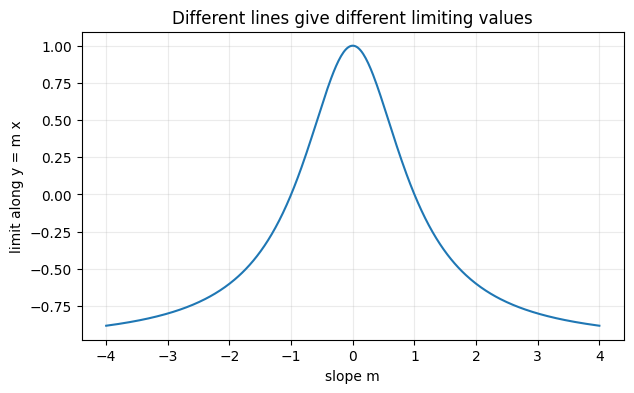

In [4]:
m_values = [-3, -1, -0.5, 0, 0.5, 1, 3]

print("Limit along y = m x:")
for m in m_values:
    path_value = (1 - m**2) / (1 + m**2)
    print(f"m = {m:5.2f}, path limit = {path_value: .6f}")

m_grid = np.linspace(-4, 4, 400)
path_limits = (1 - m_grid**2) / (1 + m_grid**2)

plt.figure(figsize=(7, 4))
plt.plot(m_grid, path_limits)
plt.xlabel("slope m")
plt.ylabel("limit along y = m x")
plt.title("Different lines give different limiting values")
plt.grid(True, alpha=0.25)
plt.show()

### Key lesson

Finding two paths with different limiting values is enough to prove that a multivariable limit **does not exist**.

However, checking many paths and seeing the same value is not a proof that the limit exists. It is only evidence.

---

# Part II. Path testing with lines and curves

A path test means replacing $(x,y)$ by a path $(x(t),y(t))$ that approaches the point.

For limits at the origin, common paths include:

$$
(x,y)=(t,0),\quad (0,t),\quad (t,mt),\quad (t,t^2),\quad (t^2,t).
$$

## 4. A reusable path-testing function

The following function evaluates a two-variable function along several standard paths approaching the origin.

In [5]:
def path_test_origin(f, t_values=None, slopes=(-2, -1, 0, 1, 2), include_curves=True):
    if t_values is None:
        t_values = 0.5**np.arange(1, 9)
    t_values = np.asarray(t_values, dtype=float)

    results = {}

    for m in slopes:
        x = t_values
        y = m*t_values
        results[f"line y={m}x"] = safe_eval_2d(f, x, y)

    if include_curves:
        curve_paths = {
            "parabola y=x^2": (t_values, t_values**2),
            "parabola x=y^2": (t_values**2, t_values),
            "cubic y=x^3": (t_values, t_values**3),
            "sqrt path y=sqrt(x)": (t_values**2, t_values),
        }
        for name, (x, y) in curve_paths.items():
            results[name] = safe_eval_2d(f, x, y)

    return t_values, results

def summarize_path_test(f, title="Path test"):
    t_values, results = path_test_origin(f)
    print(title)
    print("=" * len(title))
    for name, vals in results.items():
        print(f"{name:22s}: last three values {vals[-3:]}")
    return t_values, results

t_values, results = summarize_path_test(f_path_dependent, "Path test for (x^2-y^2)/(x^2+y^2)")

Path test for (x^2-y^2)/(x^2+y^2)
line y=-2x            : last three values [-0.6 -0.6 -0.6]
line y=-1x            : last three values [0. 0. 0.]
line y=0x             : last three values [1. 1. 1.]
line y=1x             : last three values [0. 0. 0.]
line y=2x             : last three values [-0.6 -0.6 -0.6]
parabola y=x^2        : last three values [0.999512 0.999878 0.999969]
parabola x=y^2        : last three values [-0.999512 -0.999878 -0.999969]
cubic y=x^3           : last three values [1. 1. 1.]
sqrt path y=sqrt(x)   : last three values [-0.999512 -0.999878 -0.999969]


## 5. Plot path values versus distance scale

For a function with a limit, the path-value curves should move toward a common value as $t\to0$.

For a path-dependent function, they do not.

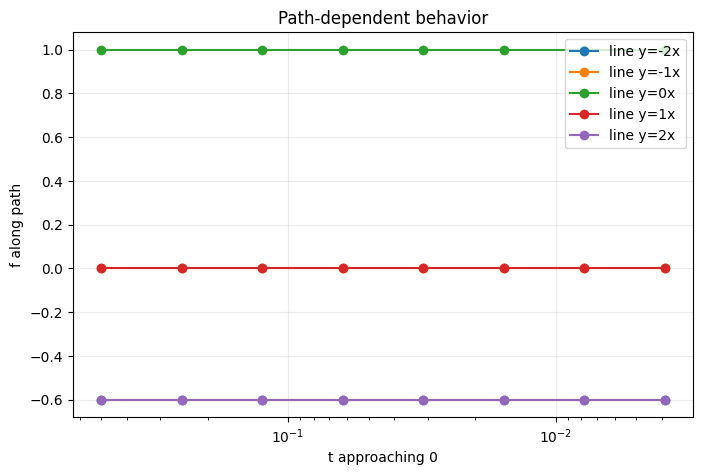

In [6]:
plt.figure(figsize=(8, 5))
for name, vals in results.items():
    if "line" in name:
        plt.plot(t_values, vals, marker="o", label=name)
plt.xscale("log")
plt.gca().invert_xaxis()
plt.xlabel("t approaching 0")
plt.ylabel("f along path")
plt.title("Path-dependent behavior")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

---

# Part III. A limit that exists

Consider

$$
f(x,y)=\frac{x^2y^2}{x^2+y^2}.
$$

At the origin, the formula is undefined, but the limit exists and equals $0$.

Reason:

$$
0\le \frac{x^2y^2}{x^2+y^2}\le \frac{(x^2+y^2)^2/4}{x^2+y^2}
=\frac{x^2+y^2}{4}\to 0.
$$

This is a squeeze theorem argument.

## 6. Numerical evidence for a squeezed limit

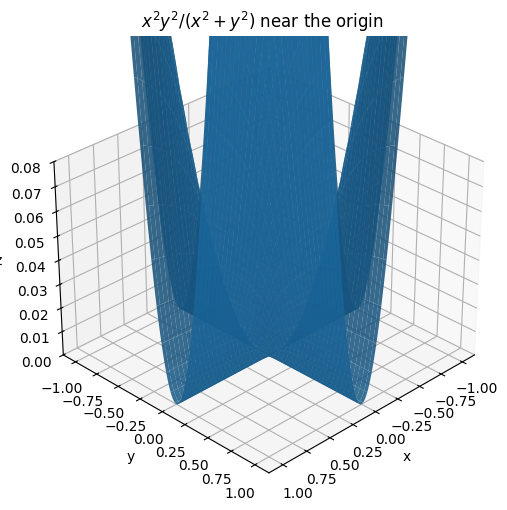

(array([[-1.      , -0.988827, -0.977654, ...,  0.977654,  0.988827,
          1.      ],
        [-1.      , -0.988827, -0.977654, ...,  0.977654,  0.988827,
          1.      ],
        [-1.      , -0.988827, -0.977654, ...,  0.977654,  0.988827,
          1.      ],
        ...,
        [-1.      , -0.988827, -0.977654, ...,  0.977654,  0.988827,
          1.      ],
        [-1.      , -0.988827, -0.977654, ...,  0.977654,  0.988827,
          1.      ],
        [-1.      , -0.988827, -0.977654, ...,  0.977654,  0.988827,
          1.      ]], shape=(180, 180)),
 array([[-1.      , -1.      , -1.      , ..., -1.      , -1.      ,
         -1.      ],
        [-0.988827, -0.988827, -0.988827, ..., -0.988827, -0.988827,
         -0.988827],
        [-0.977654, -0.977654, -0.977654, ..., -0.977654, -0.977654,
         -0.977654],
        ...,
        [ 0.977654,  0.977654,  0.977654, ...,  0.977654,  0.977654,
          0.977654],
        [ 0.988827,  0.988827,  0.988827, ...,  0.9888

In [7]:
def f_squeezed(X, Y):
    return (X**2 * Y**2) / (X**2 + Y**2)

plot_surface_near(
    f_squeezed,
    xmin=-1, xmax=1, ymin=-1, ymax=1,
    title=r"$x^2y^2/(x^2+y^2)$ near the origin",
    zlim=(0, 0.08),
    elev=30,
    azim=45
)

In [8]:
t_values, results = summarize_path_test(f_squeezed, "Path test for squeezed example")

Path test for squeezed example
line y=-2x            : last three values [0.000195 0.000049 0.000012]
line y=-1x            : last three values [0.000122 0.000031 0.000008]
line y=0x             : last three values [0. 0. 0.]
line y=1x             : last three values [0.000122 0.000031 0.000008]
line y=2x             : last three values [0.000195 0.000049 0.000012]
parabola y=x^2        : last three values [0. 0. 0.]
parabola x=y^2        : last three values [0. 0. 0.]
cubic y=x^3           : last three values [0. 0. 0.]
sqrt path y=sqrt(x)   : last three values [0. 0. 0.]


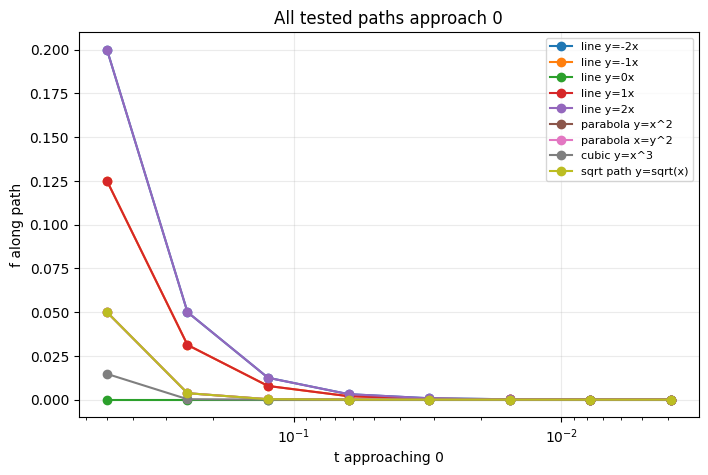

In [9]:
plt.figure(figsize=(8, 5))
for name, vals in results.items():
    plt.plot(t_values, vals, marker="o", label=name)
plt.xscale("log")
plt.gca().invert_xaxis()
plt.xlabel("t approaching 0")
plt.ylabel("f along path")
plt.title("All tested paths approach 0")
plt.legend(fontsize=8)
plt.grid(True, alpha=0.25)
plt.show()

### Radial maximum experiment

A stronger numerical check is to sample many angles on circles of radius $r$:

$$
(x,y)=(r\cos\theta,r\sin\theta).
$$

Then examine the maximum absolute value on the circle as $r\to0$.

r =  5.000000e-01, max |f| on circle =  6.250000e-02
r =  2.500000e-01, max |f| on circle =  1.562500e-02
r =  1.250000e-01, max |f| on circle =  3.906250e-03
r =  6.250000e-02, max |f| on circle =  9.765625e-04
r =  3.125000e-02, max |f| on circle =  2.441406e-04
r =  1.562500e-02, max |f| on circle =  6.103516e-05
r =  7.812500e-03, max |f| on circle =  1.525879e-05
r =  3.906250e-03, max |f| on circle =  3.814697e-06
r =  1.953125e-03, max |f| on circle =  9.536743e-07


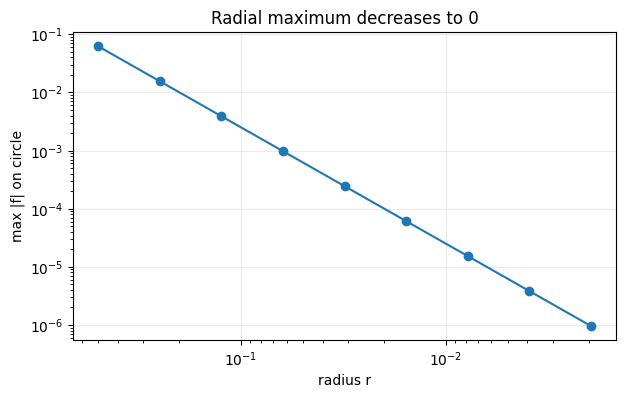

In [10]:
def radial_max_abs(f, radii, ntheta=720):
    theta = np.linspace(0, 2*np.pi, ntheta, endpoint=False)
    values = []
    for r in radii:
        X = r*np.cos(theta)
        Y = r*np.sin(theta)
        Z = safe_eval_2d(f, X, Y)
        values.append(np.nanmax(np.abs(Z)))
    return np.array(values)

radii = 0.5**np.arange(1, 10)
max_values = radial_max_abs(f_squeezed, radii)

for r, val in zip(radii, max_values):
    print(f"r = {r: .6e}, max |f| on circle = {val: .6e}")

plt.figure(figsize=(7, 4))
plt.plot(radii, max_values, marker="o")
plt.xscale("log")
plt.yscale("log")
plt.gca().invert_xaxis()
plt.xlabel("radius r")
plt.ylabel("max |f| on circle")
plt.title("Radial maximum decreases to 0")
plt.grid(True, alpha=0.25)
plt.show()

---

# Part IV. Polar coordinates for limits at the origin

For limits at $(0,0)$, use

$$
x=r\cos\theta,\qquad y=r\sin\theta.
$$

Then $(x,y)\to(0,0)$ means $r\to0$.

If the expression becomes something that tends to $L$ uniformly in $\theta$, the limit is $L$.

## 7. Polar form of a path-dependent example

For

$$
f(x,y)=\frac{x^2-y^2}{x^2+y^2},
$$

polar coordinates give

$$
f(r\cos\theta,r\sin\theta)
=
\frac{r^2\cos^2\theta-r^2\sin^2\theta}{r^2}
=
\cos(2\theta).
$$

There is no dependence on $r$, and the value depends on $\theta$.  
Therefore the limit does not exist.

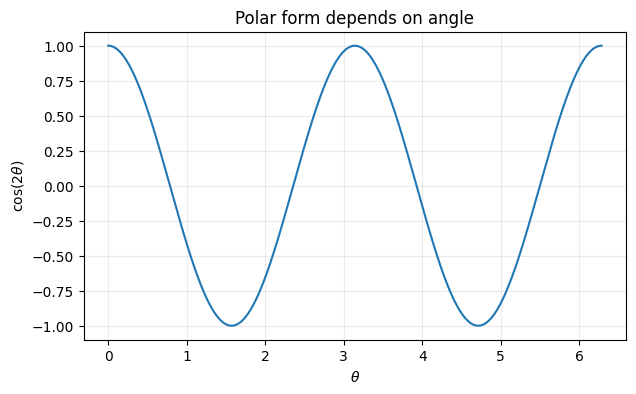

In [11]:
theta = np.linspace(0, 2*np.pi, 600)
polar_values = np.cos(2*theta)

plt.figure(figsize=(7, 4))
plt.plot(theta, polar_values)
plt.xlabel(r"$\theta$")
plt.ylabel(r"$\cos(2\theta)$")
plt.title("Polar form depends on angle")
plt.grid(True, alpha=0.25)
plt.show()

## 8. Polar form of the squeezed example

For

$$
f(x,y)=\frac{x^2y^2}{x^2+y^2},
$$

polar coordinates give

$$
f(r\cos\theta,r\sin\theta)
=
r^2\cos^2\theta\sin^2\theta.
$$

Since

$$
0\le r^2\cos^2\theta\sin^2\theta\le r^2,
$$

the limit is $0$.

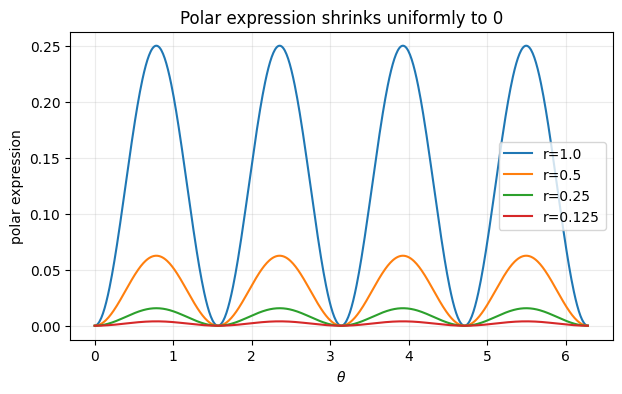

In [12]:
theta = np.linspace(0, 2*np.pi, 600)

plt.figure(figsize=(7, 4))
for r in [1.0, 0.5, 0.25, 0.125]:
    values = r**2 * np.cos(theta)**2 * np.sin(theta)**2
    plt.plot(theta, values, label=f"r={r}")
plt.xlabel(r"$\theta$")
plt.ylabel("polar expression")
plt.title("Polar expression shrinks uniformly to 0")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

## 9. Oscillatory radial example

Consider

$$
f(x,y)=\sin\left(\frac{1}{\sqrt{x^2+y^2}}\right).
$$

In polar coordinates,

$$
f=\sin(1/r).
$$

As $r\to0$, this oscillates forever and has no limit.

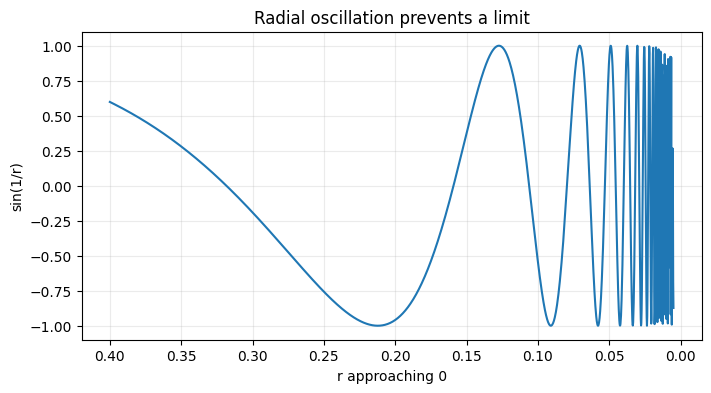

In [13]:
def f_radial_oscillatory(X, Y):
    R = np.sqrt(X**2 + Y**2)
    return np.sin(1/R)

r = np.linspace(0.005, 0.4, 2000)
values = np.sin(1/r)

plt.figure(figsize=(8, 4))
plt.plot(r, values)
plt.gca().invert_xaxis()
plt.xlabel("r approaching 0")
plt.ylabel("sin(1/r)")
plt.title("Radial oscillation prevents a limit")
plt.grid(True, alpha=0.25)
plt.show()

## 10. Oscillation killed by a factor

Now consider

$$
g(x,y)=\sqrt{x^2+y^2}\sin\left(\frac{1}{\sqrt{x^2+y^2}}\right).
$$

In polar coordinates,

$$
g=r\sin(1/r).
$$

Since

$$
|r\sin(1/r)|\le r,
$$

the limit is $0$.

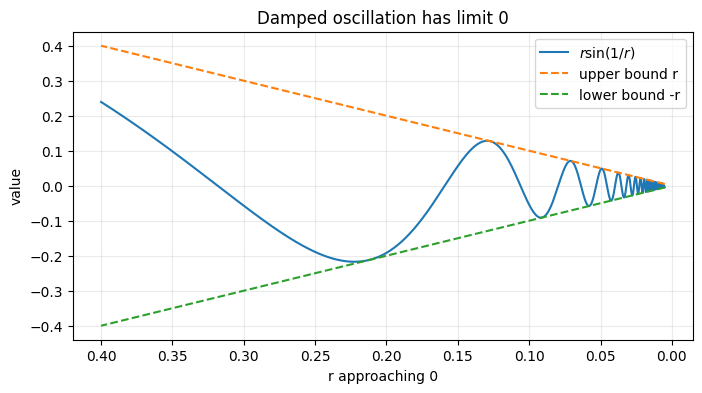

In [14]:
def f_damped_oscillatory(X, Y):
    R = np.sqrt(X**2 + Y**2)
    return R*np.sin(1/R)

r = np.linspace(0.005, 0.4, 2000)
values = r*np.sin(1/r)

plt.figure(figsize=(8, 4))
plt.plot(r, values, label=r"$r\sin(1/r)$")
plt.plot(r, r, linestyle="--", label="upper bound r")
plt.plot(r, -r, linestyle="--", label="lower bound -r")
plt.gca().invert_xaxis()
plt.xlabel("r approaching 0")
plt.ylabel("value")
plt.title("Damped oscillation has limit 0")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

---

# Part V. Classic examples where line tests are not enough

Sometimes every line through the origin gives the same limiting value, but the full limit still does not exist.

A standard example is

$$
f(x,y)=\frac{x^2y}{x^4+y^2}.
$$

Along any line $y=mx$, the limit is $0$.  
But along the parabola $y=x^2$, the expression becomes

$$
\frac{x^2x^2}{x^4+x^4}=\frac12.
$$

So the limit does not exist.

## 11. A function that fools line tests

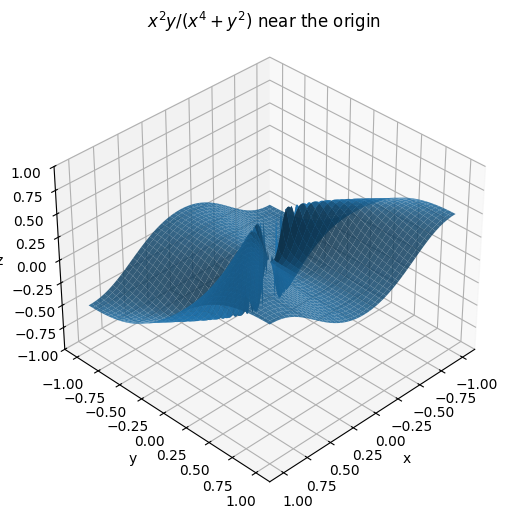

(array([[-1.      , -0.988827, -0.977654, ...,  0.977654,  0.988827,
          1.      ],
        [-1.      , -0.988827, -0.977654, ...,  0.977654,  0.988827,
          1.      ],
        [-1.      , -0.988827, -0.977654, ...,  0.977654,  0.988827,
          1.      ],
        ...,
        [-1.      , -0.988827, -0.977654, ...,  0.977654,  0.988827,
          1.      ],
        [-1.      , -0.988827, -0.977654, ...,  0.977654,  0.988827,
          1.      ],
        [-1.      , -0.988827, -0.977654, ...,  0.977654,  0.988827,
          1.      ]], shape=(180, 180)),
 array([[-1.      , -1.      , -1.      , ..., -1.      , -1.      ,
         -1.      ],
        [-0.988827, -0.988827, -0.988827, ..., -0.988827, -0.988827,
         -0.988827],
        [-0.977654, -0.977654, -0.977654, ..., -0.977654, -0.977654,
         -0.977654],
        ...,
        [ 0.977654,  0.977654,  0.977654, ...,  0.977654,  0.977654,
          0.977654],
        [ 0.988827,  0.988827,  0.988827, ...,  0.9888

In [15]:
def f_fools_lines(X, Y):
    return (X**2 * Y) / (X**4 + Y**2)

plot_surface_near(
    f_fools_lines,
    xmin=-1, xmax=1, ymin=-1, ymax=1,
    title=r"$x^2y/(x^4+y^2)$ near the origin",
    zlim=(-1, 1),
    elev=35,
    azim=45
)

In [16]:
t_values = 0.5**np.arange(1, 10)

# Lines y = m x
for m in [-2, -1, 0, 1, 2]:
    vals = safe_eval_2d(f_fools_lines, t_values, m*t_values)
    print(f"Line y={m}x, last values:", vals[-3:])

# Parabola y = x^2
vals_parabola = safe_eval_2d(f_fools_lines, t_values, t_values**2)
print("\nParabola y=x^2, last values:", vals_parabola[-3:])

Line y=-2x, last values: [-0.003906 -0.001953 -0.000977]
Line y=-1x, last values: [-0.007812 -0.003906 -0.001953]
Line y=0x, last values: [0. 0. 0.]
Line y=1x, last values: [0.007812 0.003906 0.001953]
Line y=2x, last values: [0.003906 0.001953 0.000977]

Parabola y=x^2, last values: [0.5 0.5 0.5]


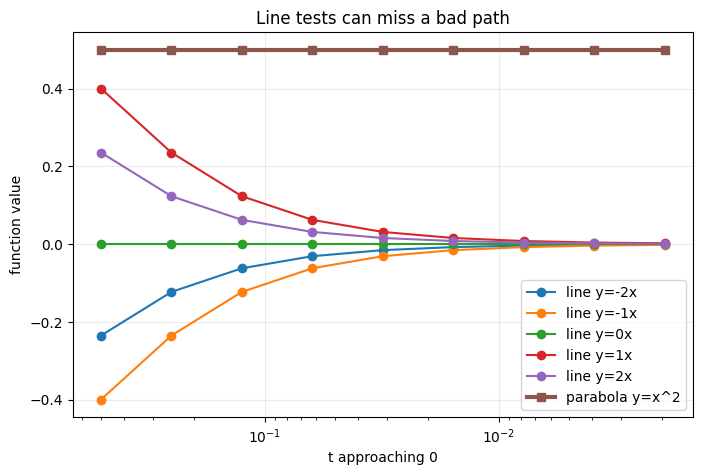

In [17]:
plt.figure(figsize=(8, 5))
for m in [-2, -1, 0, 1, 2]:
    vals = safe_eval_2d(f_fools_lines, t_values, m*t_values)
    plt.plot(t_values, vals, marker="o", label=f"line y={m}x")

vals_parabola = safe_eval_2d(f_fools_lines, t_values, t_values**2)
plt.plot(t_values, vals_parabola, marker="s", linewidth=3, label="parabola y=x^2")

plt.xscale("log")
plt.gca().invert_xaxis()
plt.xlabel("t approaching 0")
plt.ylabel("function value")
plt.title("Line tests can miss a bad path")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

### Practical lesson

Line tests are useful for finding contradictions, but they are not sufficient for proving existence.  
A proof of existence usually needs an inequality, a squeeze argument, polar coordinates, continuity theorems, or a structural theorem.

---

# Part VI. Continuity

A function $f(x,y)$ is continuous at $(a,b)$ if

$$
\lim_{(x,y)\to(a,b)}f(x,y)=f(a,b).
$$

Continuity means:

1. $f(a,b)$ is defined;
2. the limit exists;
3. the limit equals the function value.

Polynomials are continuous everywhere.  
Rational functions are continuous wherever the denominator is not zero.  
Compositions of continuous functions are continuous on their domains.

## 12. A continuous polynomial surface

Let

$$
f(x,y)=x^2+xy+y^2.
$$

This function is continuous everywhere because it is a polynomial.

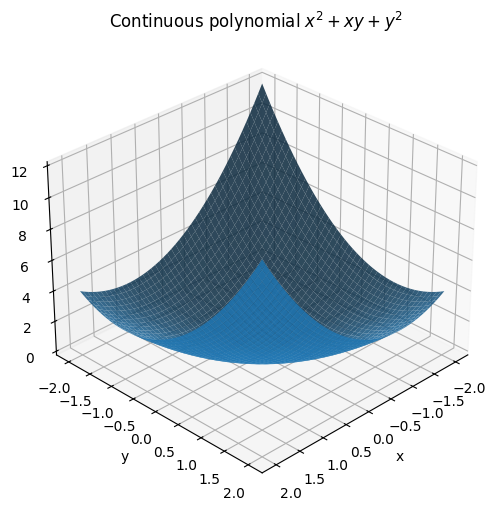

(array([[-2.      , -1.977654, -1.955307, ...,  1.955307,  1.977654,
          2.      ],
        [-2.      , -1.977654, -1.955307, ...,  1.955307,  1.977654,
          2.      ],
        [-2.      , -1.977654, -1.955307, ...,  1.955307,  1.977654,
          2.      ],
        ...,
        [-2.      , -1.977654, -1.955307, ...,  1.955307,  1.977654,
          2.      ],
        [-2.      , -1.977654, -1.955307, ...,  1.955307,  1.977654,
          2.      ],
        [-2.      , -1.977654, -1.955307, ...,  1.955307,  1.977654,
          2.      ]], shape=(180, 180)),
 array([[-2.      , -2.      , -2.      , ..., -2.      , -2.      ,
         -2.      ],
        [-1.977654, -1.977654, -1.977654, ..., -1.977654, -1.977654,
         -1.977654],
        [-1.955307, -1.955307, -1.955307, ..., -1.955307, -1.955307,
         -1.955307],
        ...,
        [ 1.955307,  1.955307,  1.955307, ...,  1.955307,  1.955307,
          1.955307],
        [ 1.977654,  1.977654,  1.977654, ...,  1.9776

In [18]:
def f_polynomial(X, Y):
    return X**2 + X*Y + Y**2

plot_surface_near(
    f_polynomial,
    xmin=-2, xmax=2, ymin=-2, ymax=2,
    title=r"Continuous polynomial $x^2+xy+y^2$",
    elev=30,
    azim=45
)

## 13. Continuity of a rational function away from denominator zero

Let

$$
f(x,y)=\frac{x+y}{x^2+y^2-1}.
$$

This function is continuous wherever

$$
x^2+y^2-1\ne0.
$$

So it is not continuous on the circle $x^2+y^2=1$.

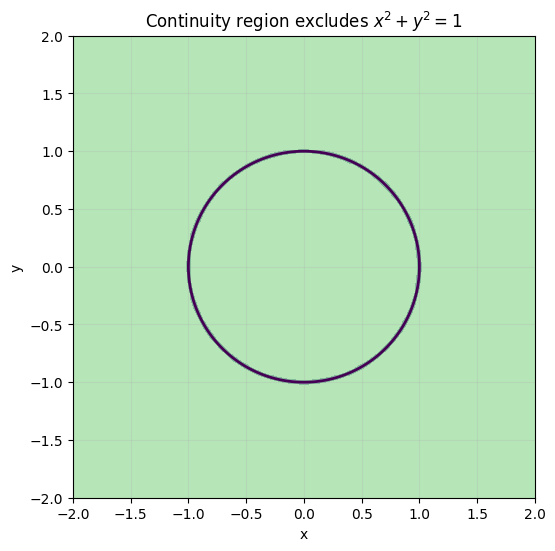

In [19]:
def f_rational(X, Y):
    return (X + Y) / (X**2 + Y**2 - 1)

x, y, X, Y = make_grid(-2, 2, -2, 2, n=500)
den = X**2 + Y**2 - 1
domain_mask = np.abs(den) > 0.03

fig, ax = plt.subplots(figsize=(6, 6))
ax.contourf(X, Y, domain_mask.astype(float), levels=[-0.5, 0.5, 1.5], alpha=0.45)
ax.contour(X, Y, X**2 + Y**2, levels=[1], linewidths=2)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(r"Continuity region excludes $x^2+y^2=1$")
ax.set_aspect("equal", adjustable="box")
ax.grid(True, alpha=0.25)
plt.show()

## 14. Removable discontinuity

Consider

$$
f(x,y)=\frac{x^2+y^2}{\sqrt{x^2+y^2}}
$$

for $(x,y)\ne(0,0)$.

This simplifies to

$$
f(x,y)=\sqrt{x^2+y^2}.
$$

The limit at the origin is $0$. If we define $f(0,0)=0$, the function becomes continuous.

r= 5.000000e-01, max |f| on circle= 5.000000e-01
r= 2.500000e-01, max |f| on circle= 2.500000e-01
r= 1.250000e-01, max |f| on circle= 1.250000e-01
r= 6.250000e-02, max |f| on circle= 6.250000e-02
r= 3.125000e-02, max |f| on circle= 3.125000e-02
r= 1.562500e-02, max |f| on circle= 1.562500e-02
r= 7.812500e-03, max |f| on circle= 7.812500e-03
r= 3.906250e-03, max |f| on circle= 3.906250e-03
r= 1.953125e-03, max |f| on circle= 1.953125e-03


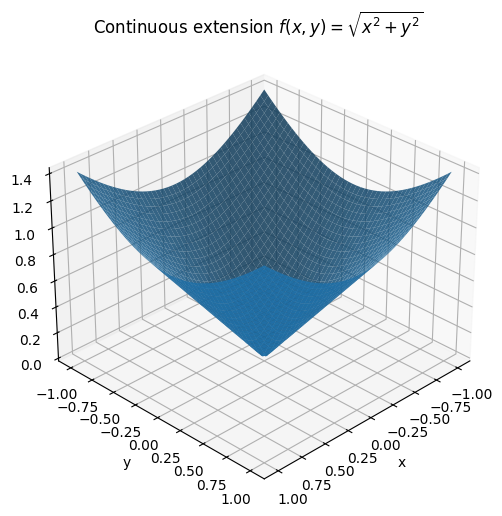

(array([[-1.      , -0.988827, -0.977654, ...,  0.977654,  0.988827,
          1.      ],
        [-1.      , -0.988827, -0.977654, ...,  0.977654,  0.988827,
          1.      ],
        [-1.      , -0.988827, -0.977654, ...,  0.977654,  0.988827,
          1.      ],
        ...,
        [-1.      , -0.988827, -0.977654, ...,  0.977654,  0.988827,
          1.      ],
        [-1.      , -0.988827, -0.977654, ...,  0.977654,  0.988827,
          1.      ],
        [-1.      , -0.988827, -0.977654, ...,  0.977654,  0.988827,
          1.      ]], shape=(180, 180)),
 array([[-1.      , -1.      , -1.      , ..., -1.      , -1.      ,
         -1.      ],
        [-0.988827, -0.988827, -0.988827, ..., -0.988827, -0.988827,
         -0.988827],
        [-0.977654, -0.977654, -0.977654, ..., -0.977654, -0.977654,
         -0.977654],
        ...,
        [ 0.977654,  0.977654,  0.977654, ...,  0.977654,  0.977654,
          0.977654],
        [ 0.988827,  0.988827,  0.988827, ...,  0.9888

In [20]:
def f_removable_raw(X, Y):
    R = np.sqrt(X**2 + Y**2)
    return (X**2 + Y**2) / R

def f_removable_fixed(X, Y):
    R = np.sqrt(X**2 + Y**2)
    return R

radii = 0.5**np.arange(1, 10)
max_values = radial_max_abs(f_removable_fixed, radii)

for r, val in zip(radii, max_values):
    print(f"r={r: .6e}, max |f| on circle={val: .6e}")

plot_surface_near(
    f_removable_fixed,
    xmin=-1, xmax=1, ymin=-1, ymax=1,
    title=r"Continuous extension $f(x,y)=\sqrt{x^2+y^2}$",
    elev=30,
    azim=45
)

## 15. A piecewise function made continuous

Define

$$
f(x,y)=
\begin{cases}
\frac{x^2y^2}{x^2+y^2}, & (x,y)\ne(0,0),\\
0, & (x,y)=(0,0).
\end{cases}
$$

This is continuous at the origin because the limit is $0$.

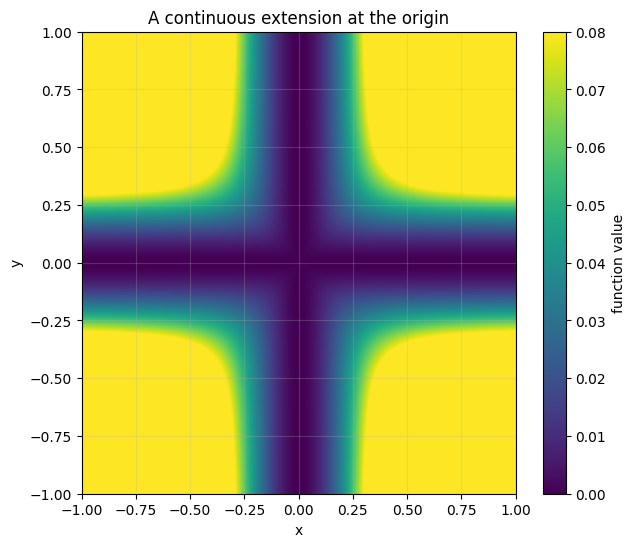

(array([[-1.      , -0.993311, -0.986622, ...,  0.986622,  0.993311,
          1.      ],
        [-1.      , -0.993311, -0.986622, ...,  0.986622,  0.993311,
          1.      ],
        [-1.      , -0.993311, -0.986622, ...,  0.986622,  0.993311,
          1.      ],
        ...,
        [-1.      , -0.993311, -0.986622, ...,  0.986622,  0.993311,
          1.      ],
        [-1.      , -0.993311, -0.986622, ...,  0.986622,  0.993311,
          1.      ],
        [-1.      , -0.993311, -0.986622, ...,  0.986622,  0.993311,
          1.      ]], shape=(300, 300)),
 array([[-1.      , -1.      , -1.      , ..., -1.      , -1.      ,
         -1.      ],
        [-0.993311, -0.993311, -0.993311, ..., -0.993311, -0.993311,
         -0.993311],
        [-0.986622, -0.986622, -0.986622, ..., -0.986622, -0.986622,
         -0.986622],
        ...,
        [ 0.986622,  0.986622,  0.986622, ...,  0.986622,  0.986622,
          0.986622],
        [ 0.993311,  0.993311,  0.993311, ...,  0.9933

In [21]:
def f_piecewise_continuous(X, Y):
    denom = X**2 + Y**2
    return np.where(denom == 0, 0, (X**2 * Y**2) / denom)

plot_heatmap_near(
    f_piecewise_continuous,
    xmin=-1, xmax=1, ymin=-1, ymax=1,
    title="A continuous extension at the origin",
    vmin=0,
    vmax=0.08
)

## 16. A piecewise function not made continuous

Define

$$
f(x,y)=
\begin{cases}
\frac{x^2-y^2}{x^2+y^2}, & (x,y)\ne(0,0),\\
0, & (x,y)=(0,0).
\end{cases}
$$

Even though a value is assigned at the origin, the function is not continuous there because the limit does not exist.

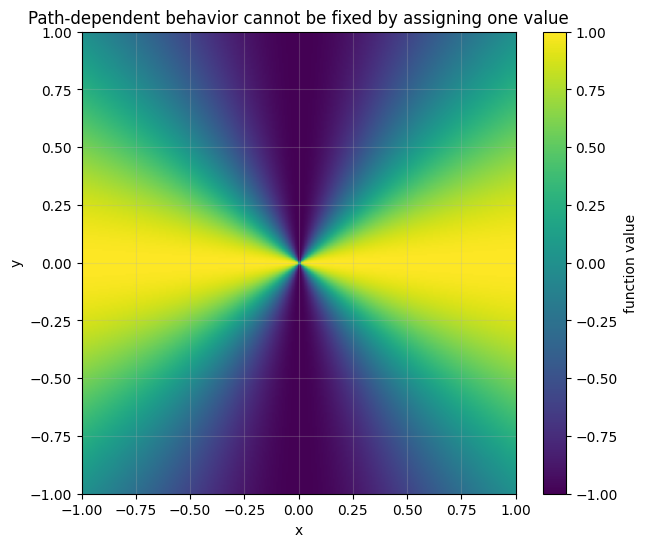

(array([[-1.      , -0.993311, -0.986622, ...,  0.986622,  0.993311,
          1.      ],
        [-1.      , -0.993311, -0.986622, ...,  0.986622,  0.993311,
          1.      ],
        [-1.      , -0.993311, -0.986622, ...,  0.986622,  0.993311,
          1.      ],
        ...,
        [-1.      , -0.993311, -0.986622, ...,  0.986622,  0.993311,
          1.      ],
        [-1.      , -0.993311, -0.986622, ...,  0.986622,  0.993311,
          1.      ],
        [-1.      , -0.993311, -0.986622, ...,  0.986622,  0.993311,
          1.      ]], shape=(300, 300)),
 array([[-1.      , -1.      , -1.      , ..., -1.      , -1.      ,
         -1.      ],
        [-0.993311, -0.993311, -0.993311, ..., -0.993311, -0.993311,
         -0.993311],
        [-0.986622, -0.986622, -0.986622, ..., -0.986622, -0.986622,
         -0.986622],
        ...,
        [ 0.986622,  0.986622,  0.986622, ...,  0.986622,  0.986622,
          0.986622],
        [ 0.993311,  0.993311,  0.993311, ...,  0.9933

In [22]:
def f_piecewise_not_continuous(X, Y):
    denom = X**2 + Y**2
    return np.where(denom == 0, 0, (X**2 - Y**2) / denom)

plot_heatmap_near(
    f_piecewise_not_continuous,
    xmin=-1, xmax=1, ymin=-1, ymax=1,
    title="Path-dependent behavior cannot be fixed by assigning one value",
    vmin=-1,
    vmax=1
)

---

# Part VII. Limits at points other than the origin

To study a limit at $(a,b)$, shift variables:

$$
u=x-a,\qquad v=y-b.
$$

Then $(x,y)\to(a,b)$ is equivalent to $(u,v)\to(0,0)$.

## 17. Path-dependent limit at $(1,2)$

Consider

$$
f(x,y)=\frac{(x-1)^2-(y-2)^2}{(x-1)^2+(y-2)^2}.
$$

This is the same path-dependent example shifted to the point $(1,2)$.

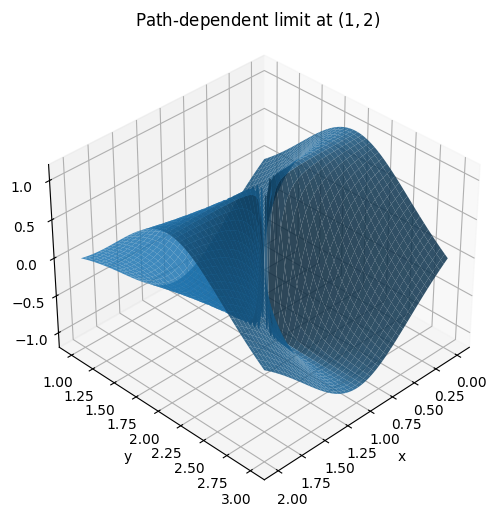

(array([[0.      , 0.011173, 0.022346, ..., 1.977654, 1.988827, 2.      ],
        [0.      , 0.011173, 0.022346, ..., 1.977654, 1.988827, 2.      ],
        [0.      , 0.011173, 0.022346, ..., 1.977654, 1.988827, 2.      ],
        ...,
        [0.      , 0.011173, 0.022346, ..., 1.977654, 1.988827, 2.      ],
        [0.      , 0.011173, 0.022346, ..., 1.977654, 1.988827, 2.      ],
        [0.      , 0.011173, 0.022346, ..., 1.977654, 1.988827, 2.      ]],
       shape=(180, 180)),
 array([[1.      , 1.      , 1.      , ..., 1.      , 1.      , 1.      ],
        [1.011173, 1.011173, 1.011173, ..., 1.011173, 1.011173, 1.011173],
        [1.022346, 1.022346, 1.022346, ..., 1.022346, 1.022346, 1.022346],
        ...,
        [2.977654, 2.977654, 2.977654, ..., 2.977654, 2.977654, 2.977654],
        [2.988827, 2.988827, 2.988827, ..., 2.988827, 2.988827, 2.988827],
        [3.      , 3.      , 3.      , ..., 3.      , 3.      , 3.      ]],
       shape=(180, 180)),
 array([[ 0.      , 

In [23]:
def f_shifted_path_dependent(X, Y):
    U = X - 1
    V = Y - 2
    return (U**2 - V**2) / (U**2 + V**2)

plot_surface_near(
    f_shifted_path_dependent,
    xmin=0, xmax=2, ymin=1, ymax=3,
    title=r"Path-dependent limit at $(1,2)$",
    zlim=(-1.2, 1.2),
    elev=35,
    azim=45
)

In [24]:
t = 0.5**np.arange(1, 9)

# Approach (1,2) horizontally and vertically.
x1 = 1 + t
y1 = 2 + 0*t
v1 = safe_eval_2d(f_shifted_path_dependent, x1, y1)

x2 = 1 + 0*t
y2 = 2 + t
v2 = safe_eval_2d(f_shifted_path_dependent, x2, y2)

print_path_table("Horizontal path: (1+t,2)", t, v1)
print()
print_path_table("Vertical path: (1,2+t)", t, v2)

Horizontal path: (1+t,2)
------------------------
t =  5.000000e-01, f =  1.0000000000
t =  2.500000e-01, f =  1.0000000000
t =  1.250000e-01, f =  1.0000000000
t =  6.250000e-02, f =  1.0000000000
t =  3.125000e-02, f =  1.0000000000
t =  1.562500e-02, f =  1.0000000000
t =  7.812500e-03, f =  1.0000000000
t =  3.906250e-03, f =  1.0000000000

Vertical path: (1,2+t)
----------------------
t =  5.000000e-01, f = -1.0000000000
t =  2.500000e-01, f = -1.0000000000
t =  1.250000e-01, f = -1.0000000000
t =  6.250000e-02, f = -1.0000000000
t =  3.125000e-02, f = -1.0000000000
t =  1.562500e-02, f = -1.0000000000
t =  7.812500e-03, f = -1.0000000000
t =  3.906250e-03, f = -1.0000000000


## 18. Continuous limit at $(1,2)$

Consider

$$
g(x,y)=e^{x+y}\cos(xy).
$$

This function is continuous everywhere, so

$$
\lim_{(x,y)\to(1,2)}g(x,y)=g(1,2)=e^3\cos 2.
$$

In [25]:
def g_continuous(X, Y):
    return np.exp(X + Y) * np.cos(X*Y)

limit_value = g_continuous(1, 2)
print("g(1,2) =", limit_value)

t = 0.5**np.arange(1, 9)
paths = {
    "(1+t, 2)": (1+t, 2 + 0*t),
    "(1, 2+t)": (1+0*t, 2+t),
    "(1+t, 2+t)": (1+t, 2+t),
    "(1+t, 2+t^2)": (1+t, 2+t**2),
}

for name, (xx, yy) in paths.items():
    vals = safe_eval_2d(g_continuous, xx, yy)
    print(name, "last three values:", vals[-3:])
print("Expected:", limit_value)

g(1,2) = -8.358532650935372
(1+t, 2) last three values: [-9.06565  -8.710658 -8.534233]
(1, 2+t) last three values: [-8.778977 -8.567635 -8.462805]
(1+t, 2+t) last three values: [-9.501849 -8.923706 -8.639492]
(1+t, 2+t^2) last three values: [-9.072396 -8.712314 -8.534643]
Expected: -8.358532650935372


---

# Part VIII. Numerical limit diagnostics

Numerical tests never replace a proof, but they can help build intuition and discover counterexamples.

A useful diagnostic samples many random directions on circles of shrinking radius around a point.

## 19. Circle-sampling diagnostic

For each radius $r$, sample many points on the circle

$$
(x,y)=(a,b)+r(\cos\theta,\sin\theta).
$$

Then compute the range of function values on that circle.

In [26]:
def circle_sample_diagnostic(f, center=(0, 0), radii=None, ntheta=720):
    if radii is None:
        radii = 0.5**np.arange(1, 9)
    radii = np.asarray(radii, dtype=float)
    theta = np.linspace(0, 2*np.pi, ntheta, endpoint=False)
    a, b = center

    summary = []
    for r in radii:
        X = a + r*np.cos(theta)
        Y = b + r*np.sin(theta)
        Z = safe_eval_2d(f, X, Y)
        summary.append({
            "r": r,
            "min": np.nanmin(Z),
            "max": np.nanmax(Z),
            "mean": np.nanmean(Z),
            "std": np.nanstd(Z),
            "range": np.nanmax(Z) - np.nanmin(Z)
        })
    return summary

def print_diagnostic(summary, title):
    print(title)
    print("=" * len(title))
    print(f"{'r':>12s} {'min':>12s} {'max':>12s} {'mean':>12s} {'std':>12s} {'range':>12s}")
    for row in summary:
        print(f"{row['r']:12.5e} {row['min']:12.5f} {row['max']:12.5f} "
              f"{row['mean']:12.5f} {row['std']:12.5f} {row['range']:12.5f}")

summary_bad = circle_sample_diagnostic(f_path_dependent)
print_diagnostic(summary_bad, "Circle diagnostic: path-dependent example")

Circle diagnostic: path-dependent example
           r          min          max         mean          std        range
 5.00000e-01     -1.00000      1.00000     -0.00000      0.70711      2.00000
 2.50000e-01     -1.00000      1.00000     -0.00000      0.70711      2.00000
 1.25000e-01     -1.00000      1.00000     -0.00000      0.70711      2.00000
 6.25000e-02     -1.00000      1.00000     -0.00000      0.70711      2.00000
 3.12500e-02     -1.00000      1.00000     -0.00000      0.70711      2.00000
 1.56250e-02     -1.00000      1.00000     -0.00000      0.70711      2.00000
 7.81250e-03     -1.00000      1.00000     -0.00000      0.70711      2.00000
 3.90625e-03     -1.00000      1.00000     -0.00000      0.70711      2.00000


In [27]:
summary_good = circle_sample_diagnostic(f_squeezed)
print_diagnostic(summary_good, "Circle diagnostic: squeezed example")

Circle diagnostic: squeezed example
           r          min          max         mean          std        range
 5.00000e-01      0.00000      0.06250      0.03125      0.02210      0.06250
 2.50000e-01      0.00000      0.01563      0.00781      0.00552      0.01563
 1.25000e-01      0.00000      0.00391      0.00195      0.00138      0.00391
 6.25000e-02      0.00000      0.00098      0.00049      0.00035      0.00098
 3.12500e-02      0.00000      0.00024      0.00012      0.00009      0.00024
 1.56250e-02      0.00000      0.00006      0.00003      0.00002      0.00006
 7.81250e-03      0.00000      0.00002      0.00001      0.00001      0.00002
 3.90625e-03      0.00000      0.00000      0.00000      0.00000      0.00000


## 20. Plot diagnostic ranges

If the range on shrinking circles goes to $0$, this suggests all directions are becoming close to one value.

If the range does not shrink, the limit likely does not exist.

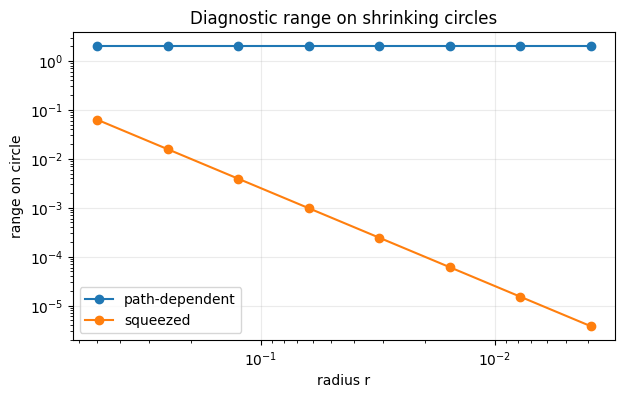

In [28]:
def diagnostic_arrays(summary):
    radii = np.array([row["r"] for row in summary])
    means = np.array([row["mean"] for row in summary])
    ranges = np.array([row["range"] for row in summary])
    stds = np.array([row["std"] for row in summary])
    return radii, means, ranges, stds

r_bad, mean_bad, range_bad, std_bad = diagnostic_arrays(summary_bad)
r_good, mean_good, range_good, std_good = diagnostic_arrays(summary_good)

plt.figure(figsize=(7, 4))
plt.plot(r_bad, range_bad, marker="o", label="path-dependent")
plt.plot(r_good, range_good, marker="o", label="squeezed")
plt.xscale("log")
plt.yscale("log")
plt.gca().invert_xaxis()
plt.xlabel("radius r")
plt.ylabel("range on circle")
plt.title("Diagnostic range on shrinking circles")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

## 21. A diagnostic class function

The following function produces a compact report. It does not prove anything, but it is useful for exploration.

Squeezed example
           r          min          max         mean          std        range
 5.00000e-01      0.00000      0.06250      0.03125      0.02210      0.06250
 2.50000e-01      0.00000      0.01563      0.00781      0.00552      0.01563
 1.25000e-01      0.00000      0.00391      0.00195      0.00138      0.00391
 6.25000e-02      0.00000      0.00098      0.00049      0.00035      0.00098
 3.12500e-02      0.00000      0.00024      0.00012      0.00009      0.00024
 1.56250e-02      0.00000      0.00006      0.00003      0.00002      0.00006
 7.81250e-03      0.00000      0.00002      0.00001      0.00001      0.00002
 3.90625e-03      0.00000      0.00000      0.00000      0.00000      0.00000


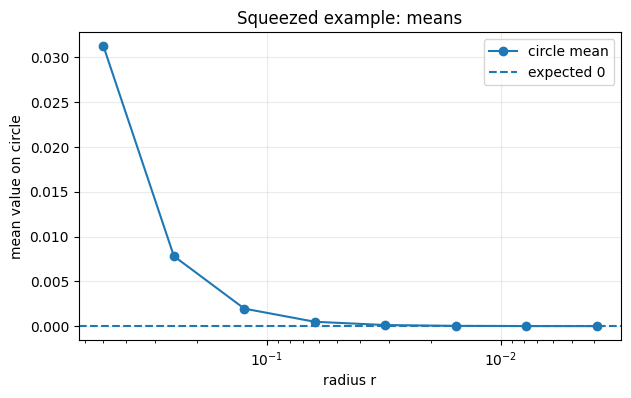

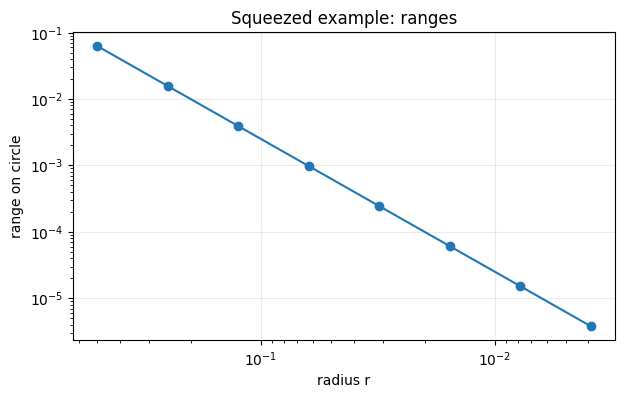

In [29]:
def numerical_limit_report(f, center=(0, 0), expected=None, title="Numerical limit report"):
    summary = circle_sample_diagnostic(f, center=center)
    print_diagnostic(summary, title)
    radii, means, ranges, stds = diagnostic_arrays(summary)

    plt.figure(figsize=(7, 4))
    plt.plot(radii, means, marker="o", label="circle mean")
    if expected is not None:
        plt.axhline(expected, linestyle="--", label=f"expected {expected}")
    plt.xscale("log")
    plt.gca().invert_xaxis()
    plt.xlabel("radius r")
    plt.ylabel("mean value on circle")
    plt.title(title + ": means")
    plt.legend()
    plt.grid(True, alpha=0.25)
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(radii, ranges, marker="o")
    plt.xscale("log")
    plt.yscale("log")
    plt.gca().invert_xaxis()
    plt.xlabel("radius r")
    plt.ylabel("range on circle")
    plt.title(title + ": ranges")
    plt.grid(True, alpha=0.25)
    plt.show()

numerical_limit_report(f_squeezed, expected=0, title="Squeezed example")

---

# Part IX. Continuity regions and domain masks

Many multivariable functions are continuous on their domains.  
Therefore, identifying the domain often gives the continuity region.

## 22. Continuity region of a square-root function

Let

$$
f(x,y)=\sqrt{4-x^2-y^2}.
$$

This function is continuous on the closed disk

$$
x^2+y^2\le4.
$$

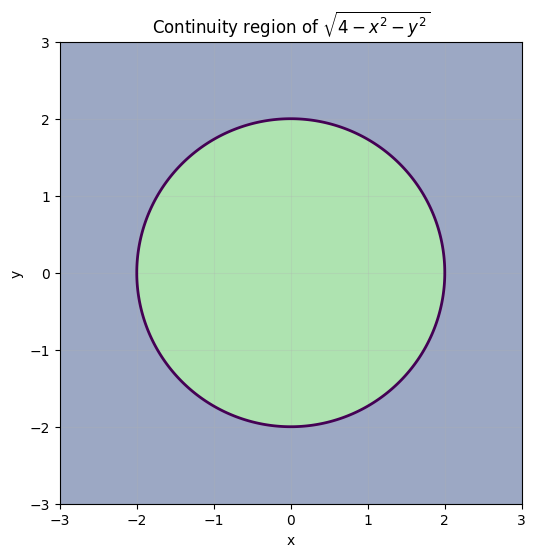

In [30]:
x, y, X, Y = make_grid(-3, 3, -3, 3, n=500)
mask = X**2 + Y**2 <= 4

fig, ax = plt.subplots(figsize=(6, 6))
ax.contourf(X, Y, mask.astype(float), levels=[-0.5, 0.5, 1.5], alpha=0.5)
ax.contour(X, Y, X**2 + Y**2, levels=[4], linewidths=2)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(r"Continuity region of $\sqrt{4-x^2-y^2}$")
ax.set_aspect("equal", adjustable="box")
ax.grid(True, alpha=0.25)
plt.show()

## 23. Continuity region of a logarithmic function

Let

$$
f(x,y)=\ln(y-x^2).
$$

The logarithm requires

$$
y-x^2>0,
$$

so the continuity region is above the parabola $y=x^2$.

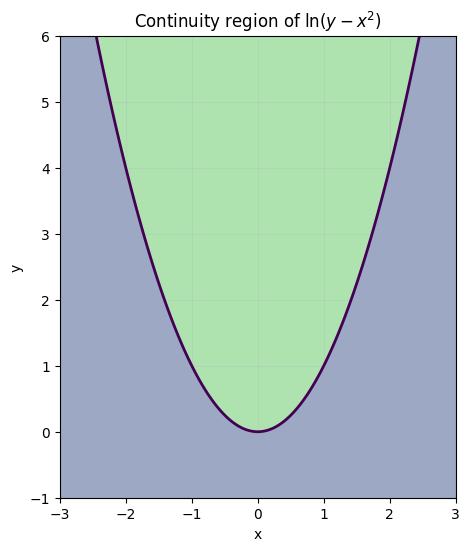

In [31]:
x, y, X, Y = make_grid(-3, 3, -1, 6, n=500)
mask = Y - X**2 > 0

fig, ax = plt.subplots(figsize=(7, 6))
ax.contourf(X, Y, mask.astype(float), levels=[-0.5, 0.5, 1.5], alpha=0.5)
ax.contour(X, Y, Y - X**2, levels=[0], linewidths=2)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(r"Continuity region of $\ln(y-x^2)$")
ax.set_aspect("equal", adjustable="box")
ax.grid(True, alpha=0.25)
plt.show()

## 24. Continuity region of a rational-square-root expression

Let

$$
f(x,y)=\frac{\sqrt{x+y}}{x-y}.
$$

Continuity requires

$$
x+y\ge0,\qquad x-y\ne0.
$$

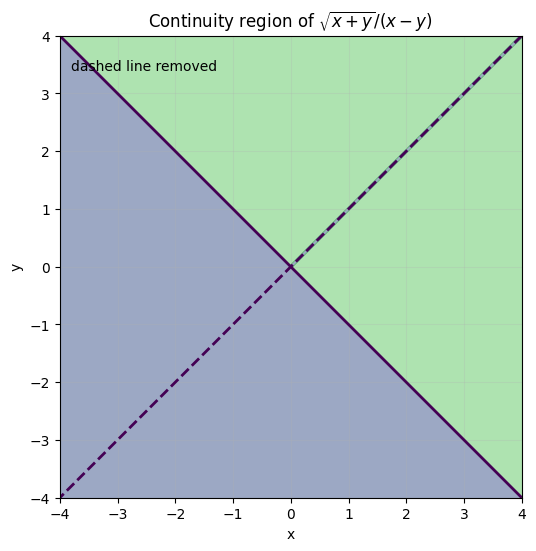

In [32]:
x, y, X, Y = make_grid(-4, 4, -4, 4, n=500)
mask = (X + Y >= 0) & (np.abs(X - Y) > 0.04)

fig, ax = plt.subplots(figsize=(7, 6))
ax.contourf(X, Y, mask.astype(float), levels=[-0.5, 0.5, 1.5], alpha=0.5)
ax.contour(X, Y, X + Y, levels=[0], linewidths=2)
ax.contour(X, Y, X - Y, levels=[0], linewidths=2, linestyles="--")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(r"Continuity region of $\sqrt{x+y}/(x-y)$")
ax.text(-3.8, 3.4, "dashed line removed")
ax.set_aspect("equal", adjustable="box")
ax.grid(True, alpha=0.25)
plt.show()

---

# Part X. Applied example: a discontinuous decision boundary

In data science, a classifier may assign a class by a discontinuous rule.

For example,

$$
C(x,y)=
\begin{cases}
1, & x^2+y^2<1,\\
0, & x^2+y^2\ge1.
\end{cases}
$$

This function is discontinuous along the circle $x^2+y^2=1$.

## 25. Classifier as a discontinuous function

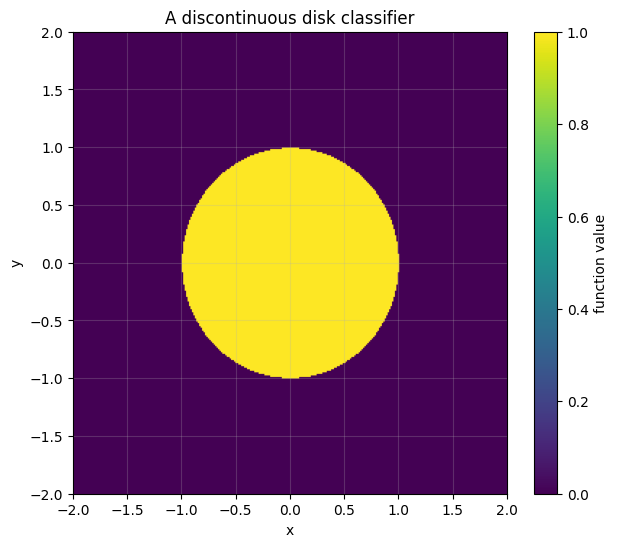

(array([[-2.      , -1.986622, -1.973244, ...,  1.973244,  1.986622,
          2.      ],
        [-2.      , -1.986622, -1.973244, ...,  1.973244,  1.986622,
          2.      ],
        [-2.      , -1.986622, -1.973244, ...,  1.973244,  1.986622,
          2.      ],
        ...,
        [-2.      , -1.986622, -1.973244, ...,  1.973244,  1.986622,
          2.      ],
        [-2.      , -1.986622, -1.973244, ...,  1.973244,  1.986622,
          2.      ],
        [-2.      , -1.986622, -1.973244, ...,  1.973244,  1.986622,
          2.      ]], shape=(300, 300)),
 array([[-2.      , -2.      , -2.      , ..., -2.      , -2.      ,
         -2.      ],
        [-1.986622, -1.986622, -1.986622, ..., -1.986622, -1.986622,
         -1.986622],
        [-1.973244, -1.973244, -1.973244, ..., -1.973244, -1.973244,
         -1.973244],
        ...,
        [ 1.973244,  1.973244,  1.973244, ...,  1.973244,  1.973244,
          1.973244],
        [ 1.986622,  1.986622,  1.986622, ...,  1.9866

In [33]:
def classifier_disk(X, Y):
    return np.where(X**2 + Y**2 < 1, 1.0, 0.0)

plot_heatmap_near(
    classifier_disk,
    xmin=-2, xmax=2, ymin=-2, ymax=2,
    title="A discontinuous disk classifier",
    vmin=0,
    vmax=1
)

## 26. Smooth approximation to the classifier

A smooth approximation is

$$
S_k(x,y)=\frac{1}{1+\exp(k(x^2+y^2-1))}.
$$

For large $k$, this looks like the discontinuous classifier, but for finite $k$ it is continuous.

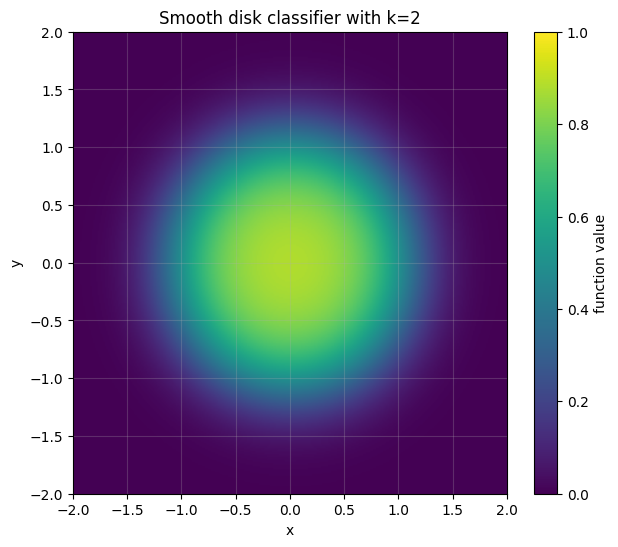

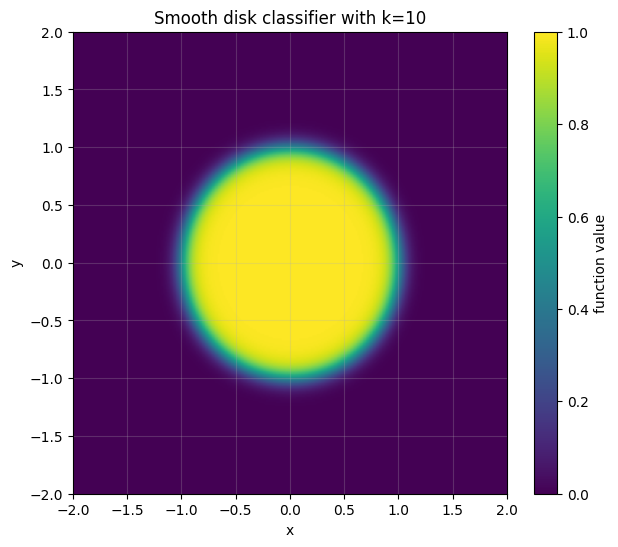

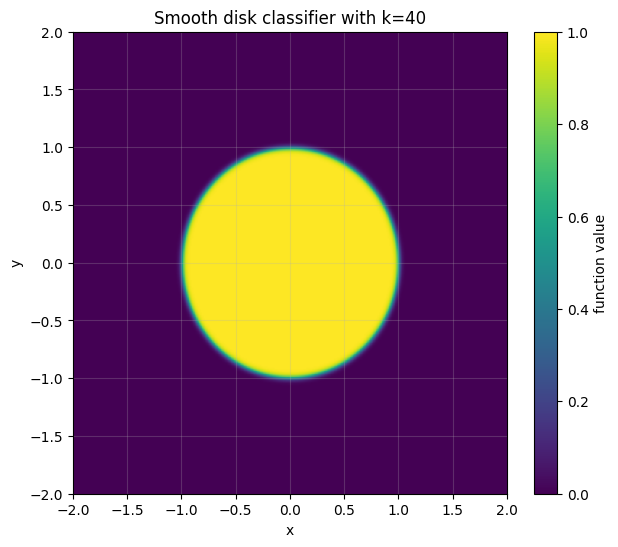

In [34]:
def smooth_disk_classifier(X, Y, k=10):
    return 1 / (1 + np.exp(k*(X**2 + Y**2 - 1)))

for k in [2, 10, 40]:
    plot_heatmap_near(
        lambda X, Y, k=k: smooth_disk_classifier(X, Y, k=k),
        xmin=-2, xmax=2, ymin=-2, ymax=2,
        title=f"Smooth disk classifier with k={k}",
        vmin=0,
        vmax=1
    )

### Interpretation

The discontinuous classifier changes instantly at the boundary.  
The smooth classifier changes rapidly but continuously.

This is one reason smooth functions are central in optimization and machine learning: they provide stable changes under small perturbations.

---

# Part XI. Chapter mini-project: limit detective

You will investigate several mystery functions at the origin.

For each function:

1. create a surface or heatmap near the origin;
2. test standard paths;
3. use circle diagnostics;
4. decide whether the limit appears to exist;
5. give a mathematical explanation.

## 27. Mystery functions

The functions are:

$$
f_1(x,y)=\frac{xy}{x^2+y^2},
$$

$$
f_2(x,y)=\frac{x^2y^2}{x^2+y^2},
$$

$$
f_3(x,y)=\frac{x^3+y^3}{x^2+y^2},
$$

$$
f_4(x,y)=\frac{x^2y}{x^4+y^2}.
$$

In [35]:
def f1(X, Y):
    return (X*Y) / (X**2 + Y**2)

def f2(X, Y):
    return (X**2 * Y**2) / (X**2 + Y**2)

def f3(X, Y):
    return (X**3 + Y**3) / (X**2 + Y**2)

def f4(X, Y):
    return (X**2 * Y) / (X**4 + Y**2)

mystery_functions = {
    "f1 = xy/(x^2+y^2)": f1,
    "f2 = x^2y^2/(x^2+y^2)": f2,
    "f3 = (x^3+y^3)/(x^2+y^2)": f3,
    "f4 = x^2y/(x^4+y^2)": f4,
}

## 28. Visual scan

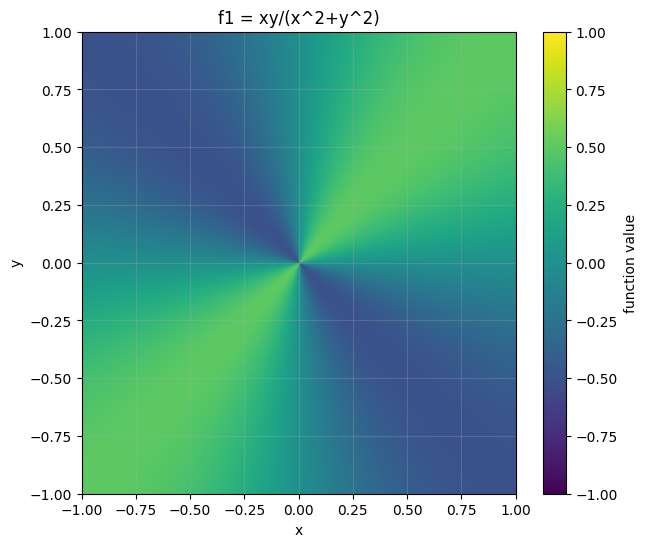

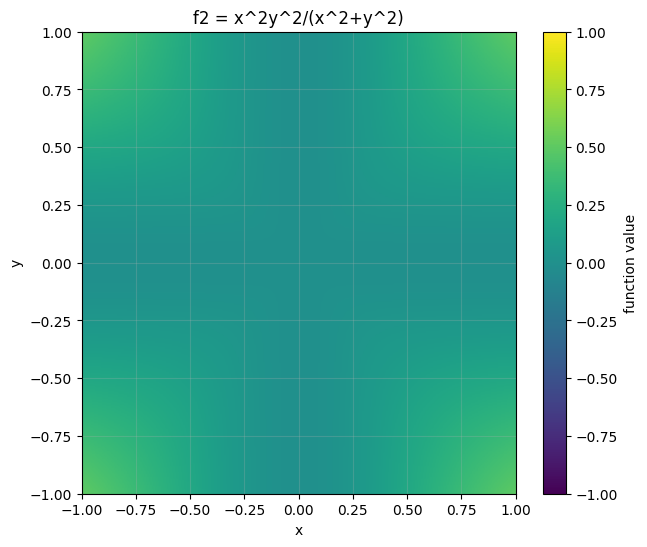

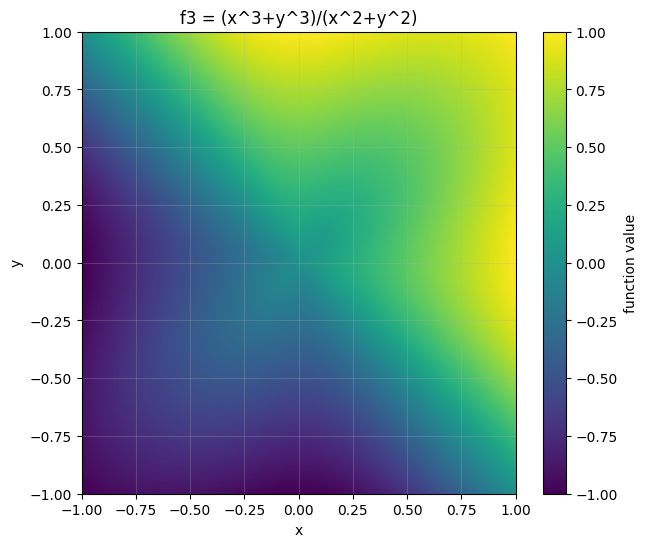

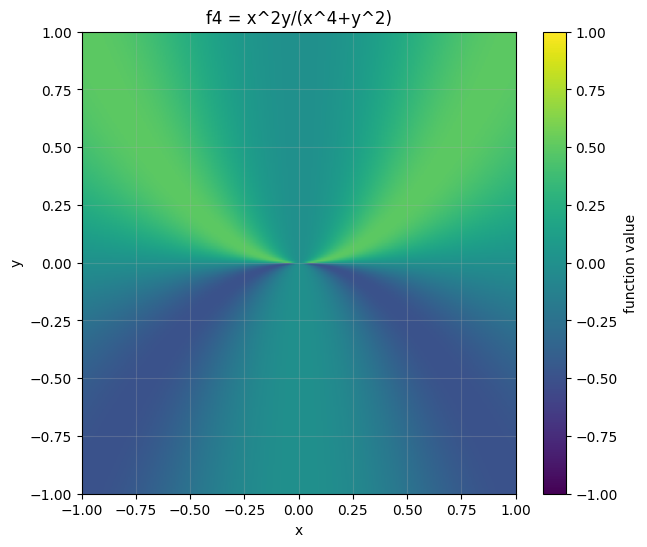

In [36]:
for name, func in mystery_functions.items():
    plot_heatmap_near(
        func,
        xmin=-1, xmax=1, ymin=-1, ymax=1,
        title=name,
        vmin=-1,
        vmax=1
    )

## 29. Path scan

In [37]:
for name, func in mystery_functions.items():
    print()
    summarize_path_test(func, f"Path test: {name}")


Path test: f1 = xy/(x^2+y^2)
line y=-2x            : last three values [-0.4 -0.4 -0.4]
line y=-1x            : last three values [-0.5 -0.5 -0.5]
line y=0x             : last three values [0. 0. 0.]
line y=1x             : last three values [0.5 0.5 0.5]
line y=2x             : last three values [0.4 0.4 0.4]
parabola y=x^2        : last three values [0.015621 0.007812 0.003906]
parabola x=y^2        : last three values [0.015621 0.007812 0.003906]
cubic y=x^3           : last three values [0.000244 0.000061 0.000015]
sqrt path y=sqrt(x)   : last three values [0.015621 0.007812 0.003906]

Path test: f2 = x^2y^2/(x^2+y^2)
line y=-2x            : last three values [0.000195 0.000049 0.000012]
line y=-1x            : last three values [0.000122 0.000031 0.000008]
line y=0x             : last three values [0. 0. 0.]
line y=1x             : last three values [0.000122 0.000031 0.000008]
line y=2x             : last three values [0.000195 0.000049 0.000012]
parabola y=x^2        : last thr

## 30. Circle diagnostic scan

In [38]:
for name, func in mystery_functions.items():
    print()
    summary = circle_sample_diagnostic(func)
    print_diagnostic(summary, f"Circle diagnostic: {name}")


Circle diagnostic: f1 = xy/(x^2+y^2)
           r          min          max         mean          std        range
 5.00000e-01     -0.50000      0.50000      0.00000      0.35355      1.00000
 2.50000e-01     -0.50000      0.50000      0.00000      0.35355      1.00000
 1.25000e-01     -0.50000      0.50000      0.00000      0.35355      1.00000
 6.25000e-02     -0.50000      0.50000      0.00000      0.35355      1.00000
 3.12500e-02     -0.50000      0.50000      0.00000      0.35355      1.00000
 1.56250e-02     -0.50000      0.50000      0.00000      0.35355      1.00000
 7.81250e-03     -0.50000      0.50000      0.00000      0.35355      1.00000
 3.90625e-03     -0.50000      0.50000      0.00000      0.35355      1.00000

Circle diagnostic: f2 = x^2y^2/(x^2+y^2)
           r          min          max         mean          std        range
 5.00000e-01      0.00000      0.06250      0.03125      0.02210      0.06250
 2.50000e-01      0.00000      0.01563      0.00781      0.005

## 31. Project response template

Fill in this table in a markdown cell.

| Function | Numerical evidence | Limit exists? | Limit value if it exists | Mathematical reason |
|---|---|---:|---:|---|
| $f_1$ | | | | |
| $f_2$ | | | | |
| $f_3$ | | | | |
| $f_4$ | | | | |

Hints:

- For $f_1$, compare $y=x$ and $y=-x$.
- For $f_2$, use a squeeze bound.
- For $f_3$, try polar coordinates and bound the expression by a constant times $r$.
- For $f_4$, compare lines with the parabola $y=x^2$.

---

# Part XII. Additional exercises with reference solutions

Try each exercise before running the reference solution.

## Exercise A. Two paths, no limit

Show numerically and mathematically that

$$
\lim_{(x,y)\to(0,0)}\frac{xy}{x^2+y^2}
$$

does not exist.

In [39]:
# Exercise A workspace

def exercise_A_f(X, Y):
    return (X*Y) / (X**2 + Y**2)

# Your code here

### Reference solution for Exercise A

In [40]:
t = 0.5**np.arange(1, 9)

vals_y_equals_x = safe_eval_2d(exercise_A_f, t, t)
vals_y_equals_neg_x = safe_eval_2d(exercise_A_f, t, -t)

print("Along y=x, values:", vals_y_equals_x[-4:])
print("Along y=-x, values:", vals_y_equals_neg_x[-4:])
print("The path limits are 1/2 and -1/2, so the two-variable limit does not exist.")

Along y=x, values: [0.5 0.5 0.5 0.5]
Along y=-x, values: [-0.5 -0.5 -0.5 -0.5]
The path limits are 1/2 and -1/2, so the two-variable limit does not exist.


## Exercise B. A limit equal to zero

Investigate

$$
\lim_{(x,y)\to(0,0)}\frac{x^3+y^3}{x^2+y^2}.
$$

Use numerical evidence and explain why the limit is $0$.

In [41]:
# Exercise B workspace

def exercise_B_f(X, Y):
    return (X**3 + Y**3) / (X**2 + Y**2)

# Your code here

### Reference solution for Exercise B

In [42]:
summary = circle_sample_diagnostic(exercise_B_f)
print_diagnostic(summary, "Exercise B diagnostic")

# Explanation:
# In polar coordinates, numerator is r^3(cos^3 theta + sin^3 theta),
# denominator is r^2, so the expression is r(cos^3 theta + sin^3 theta).
# This is bounded in absolute value by 2r, so the limit is 0.

Exercise B diagnostic
           r          min          max         mean          std        range
 5.00000e-01     -0.50000      0.50000      0.00000      0.39528      1.00000
 2.50000e-01     -0.25000      0.25000      0.00000      0.19764      0.50000
 1.25000e-01     -0.12500      0.12500      0.00000      0.09882      0.25000
 6.25000e-02     -0.06250      0.06250      0.00000      0.04941      0.12500
 3.12500e-02     -0.03125      0.03125      0.00000      0.02471      0.06250
 1.56250e-02     -0.01562      0.01562      0.00000      0.01235      0.03125
 7.81250e-03     -0.00781      0.00781      0.00000      0.00618      0.01562
 3.90625e-03     -0.00391      0.00391      0.00000      0.00309      0.00781


## Exercise C. Continuity region

Find and plot the continuity region of

$$
f(x,y)=\ln(9-x^2-y^2).
$$

In [43]:
# Exercise C workspace

# Your code here

### Reference solution for Exercise C

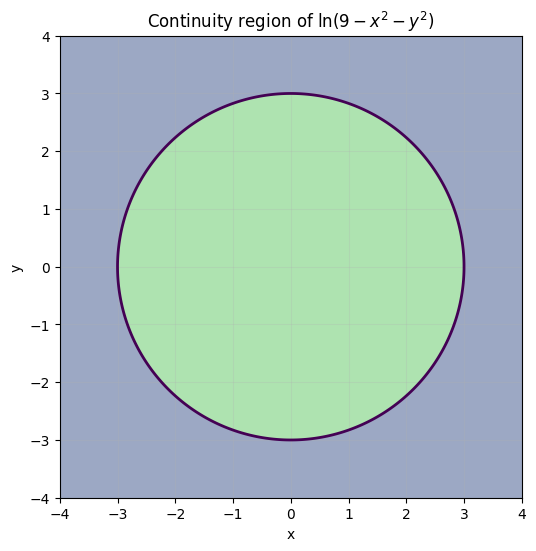

Continuity region: x^2 + y^2 < 9


In [44]:
x, y, X, Y = make_grid(-4, 4, -4, 4, n=500)
mask = 9 - X**2 - Y**2 > 0

fig, ax = plt.subplots(figsize=(6, 6))
ax.contourf(X, Y, mask.astype(float), levels=[-0.5, 0.5, 1.5], alpha=0.5)
ax.contour(X, Y, X**2 + Y**2, levels=[9], linewidths=2)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(r"Continuity region of $\ln(9-x^2-y^2)$")
ax.grid(True, alpha=0.25)
plt.show()

print("Continuity region: x^2 + y^2 < 9")

## Exercise D. Removable discontinuity

Consider

$$
f(x,y)=\frac{\sin(x^2+y^2)}{x^2+y^2}.
$$

What is the limit as $(x,y)\to(0,0)$? How should $f(0,0)$ be defined to make the function continuous?

In [45]:
# Exercise D workspace

def exercise_D_f(X, Y):
    R2 = X**2 + Y**2
    return np.sin(R2) / R2

# Your code here

### Reference solution for Exercise D

In [46]:
def exercise_D_radial(r):
    return np.sin(r**2) / r**2

r = 0.5**np.arange(1, 12)
vals = exercise_D_radial(r)

for rr, vv in zip(r, vals):
    print(f"r={rr: .6e}, value={vv:.10f}")

print("\nThe limit is 1 because sin(u)/u -> 1 as u -> 0.")
print("Define f(0,0)=1 to make the function continuous.")

r= 5.000000e-01, value=0.9896158370
r= 2.500000e-01, value=0.9993490855
r= 1.250000e-01, value=0.9999593104
r= 6.250000e-02, value=0.9999974569
r= 3.125000e-02, value=0.9999998411
r= 1.562500e-02, value=0.9999999901
r= 7.812500e-03, value=0.9999999994
r= 3.906250e-03, value=1.0000000000
r= 1.953125e-03, value=1.0000000000
r= 9.765625e-04, value=1.0000000000
r= 4.882812e-04, value=1.0000000000

The limit is 1 because sin(u)/u -> 1 as u -> 0.
Define f(0,0)=1 to make the function continuous.


## Exercise E. Shifted continuity

Let

$$
f(x,y)=\frac{(x-2)^2(y+1)^2}{(x-2)^2+(y+1)^2}
$$

for $(x,y)\ne(2,-1)$.

Find the limit as $(x,y)\to(2,-1)$.

In [47]:
# Exercise E workspace

def exercise_E_f(X, Y):
    U = X - 2
    V = Y + 1
    return (U**2 * V**2) / (U**2 + V**2)

# Your code here

### Reference solution for Exercise E

In [48]:
summary = circle_sample_diagnostic(exercise_E_f, center=(2, -1))
print_diagnostic(summary, "Exercise E diagnostic at (2,-1)")

print("\nThe expression is the squeezed example shifted to (2,-1), so the limit is 0.")

Exercise E diagnostic at (2,-1)
           r          min          max         mean          std        range
 5.00000e-01      0.00000      0.06250      0.03125      0.02210      0.06250
 2.50000e-01      0.00000      0.01563      0.00781      0.00552      0.01563
 1.25000e-01      0.00000      0.00391      0.00195      0.00138      0.00391
 6.25000e-02      0.00000      0.00098      0.00049      0.00035      0.00098
 3.12500e-02      0.00000      0.00024      0.00012      0.00009      0.00024
 1.56250e-02      0.00000      0.00006      0.00003      0.00002      0.00006
 7.81250e-03      0.00000      0.00002      0.00001      0.00001      0.00002
 3.90625e-03      0.00000      0.00000      0.00000      0.00000      0.00000

The expression is the squeezed example shifted to (2,-1), so the limit is 0.


---

# Formula summary

## Distance to a point

$$
\operatorname{dist}((x,y),(a,b))
=
\sqrt{(x-a)^2+(y-b)^2}.
$$

## Limit of a function of two variables

$$
\lim_{(x,y)\to(a,b)}f(x,y)=L
$$

means $f(x,y)$ gets close to $L$ whenever $(x,y)$ is sufficiently close to $(a,b)$.

## Continuity at a point

$$
f\text{ is continuous at }(a,b)
\quad\Longleftrightarrow\quad
\lim_{(x,y)\to(a,b)}f(x,y)=f(a,b).
$$

## Polar substitution at the origin

$$
x=r\cos\theta,\qquad y=r\sin\theta.
$$

## Common strategy for proving a limit exists

Show

$$
|f(x,y)-L|\le M\cdot r^\alpha,
\qquad
r=\sqrt{x^2+y^2},\quad \alpha>0.
$$

Then $f(x,y)\to L$ as $r\to0$.

# End of Chapter 7 Lab

You have used Python to explore:

- path-dependent limits,
- limits that exist by squeezing,
- polar-coordinate diagnostics,
- radial oscillation,
- removable discontinuities,
- continuity regions,
- discontinuous decision boundaries,
- and numerical limit detection.

These ideas prepare for partial derivatives, differentiability, gradients, tangent planes, optimization, and multivariable integration.